<a href="https://colab.research.google.com/github/Thienluong9999/IoT_ph-ng_kh-m_th-_y/blob/main/MLTrain_Notebook/Notebook/ML/MLEsp32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MQ2_pct_change    0
MQ3_pct_change    0
MQ4_pct_change    0
dtype: int64

========== Cluster Center ==========

L0 | centroid = -4.858% | samples = 5622
L1 | centroid = -0.011% | samples = 68919
L2 | centroid = 6.822% | samples = 2891
L3 | centroid = 18.504% | samples = 783

========== Pollution Level ==========

pollution_level
0     5622
1    68919
2     2891
3      783
Name: count, dtype: int64

========== Feature Engineering Data ==========

Số lượng features đầu vào: 22 (bao gồm Hour_sin/cos)
Target dự báo: target_t5

    MQ2_pct_change_lag0_zscore  MQ2_pct_change_lag1_zscore  Hour_sin  \
21                   -1.096452                   -1.261797 -0.965926   
22                   -0.960298                   -1.096452 -0.965926   
23                   -0.844619                   -0.960298 -0.965926   
24                   -0.744036                   -0.844619 -0.965926   
25                   -1.117014                   -0.744036 -0.965926   

    target_t5  
21  -0.398406  
22  -0

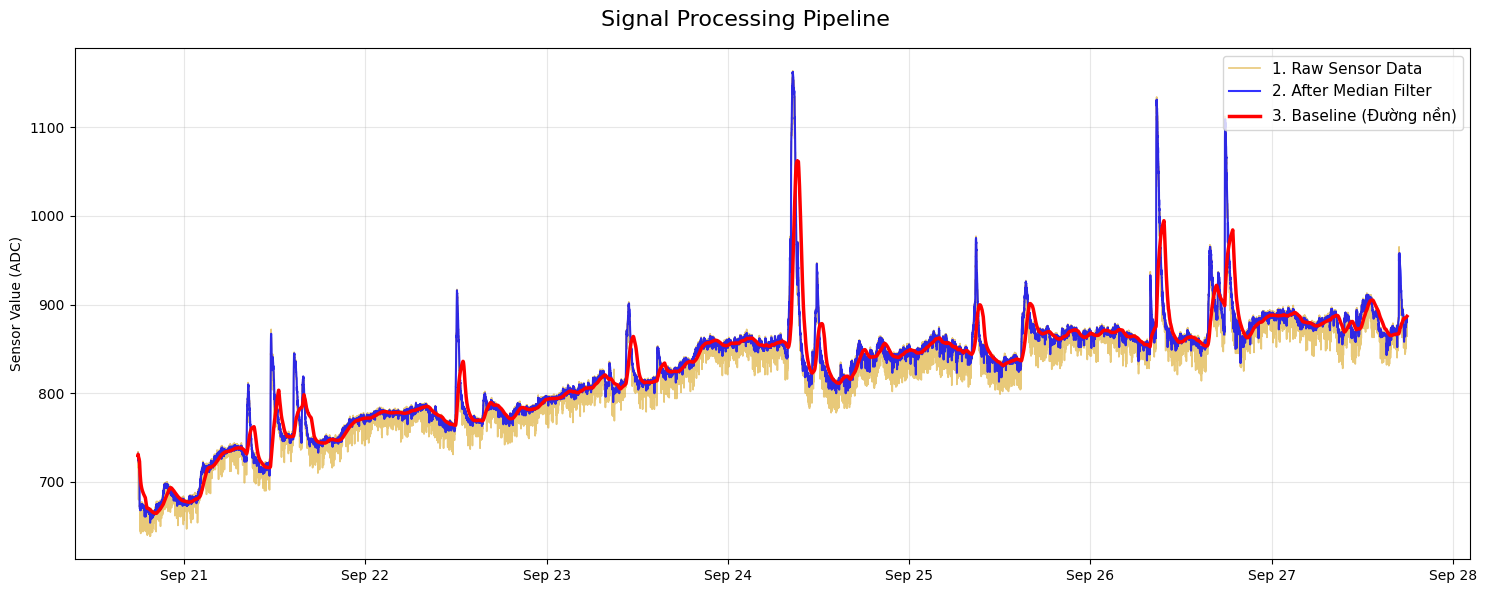

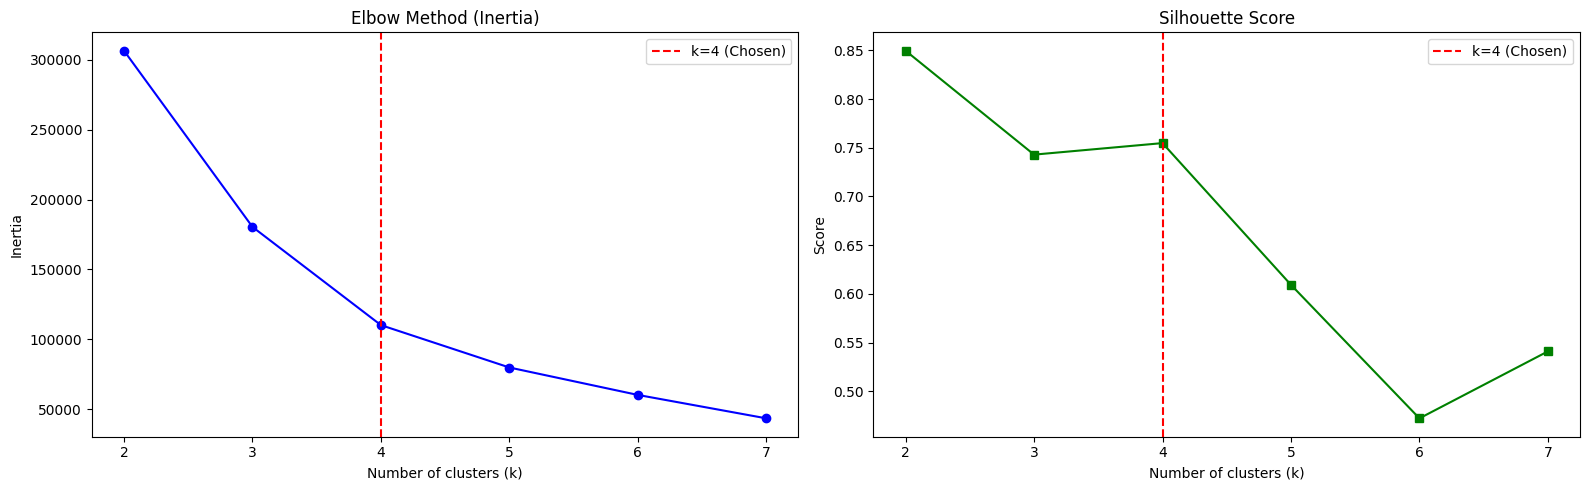

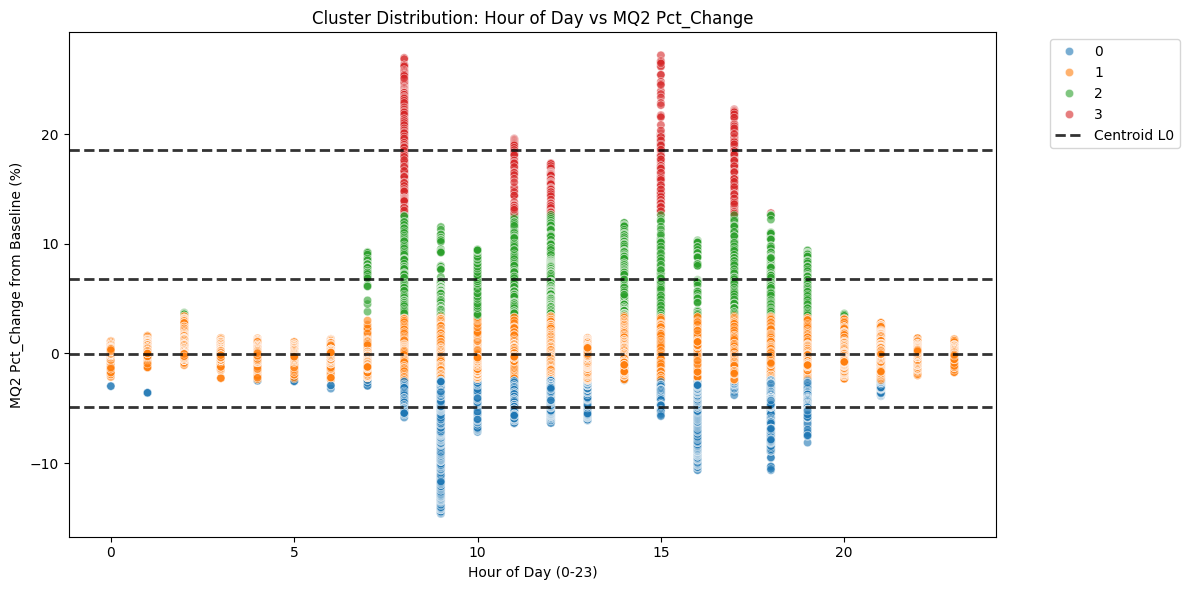

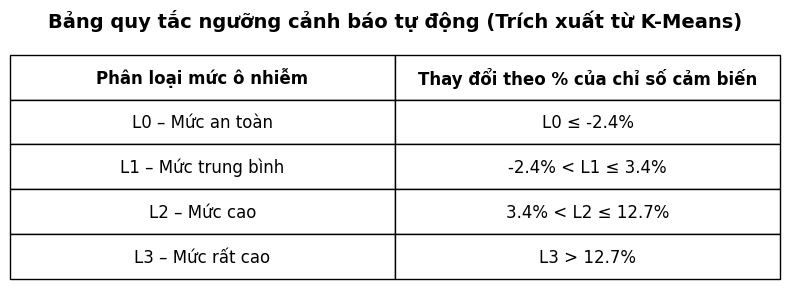

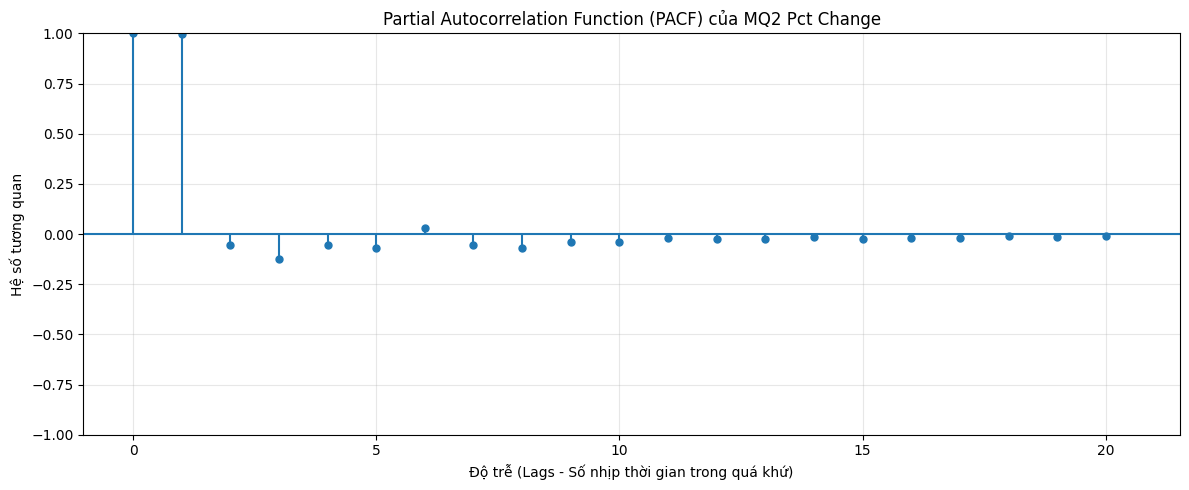


========== CHẠY ABLATION TEST SO SÁNH LAG ==========

Đang chạy test kịch bản: current_1_6_18 (Lags: [1, 6, 18]) ...
Đang chạy test kịch bản: pacf_peaks_old (Lags: [1, 3, 8]) ...
Đang chạy test kịch bản: lag1_only (Lags: [1]) ...
Đang chạy test kịch bản: dense_short (Lags: [1, 2, 3, 4, 5]) ...
Đang chạy test kịch bản: pacf_strongest_1_3 (Lags: [1, 3]) ...
Đang chạy test kịch bản: pacf_visible_peaks_1_3_6 (Lags: [1, 3, 6]) ...

========== BẢNG TỔNG HỢP KẾT QUẢ ABLATION TEST ==========

| Kịch bản (Tên)           | Cấu hình Lags   |   Số lượng Features |   RMSE Baseline |   RMSE MOLR |   Cải thiện (%) |
|:-------------------------|:----------------|--------------------:|----------------:|------------:|----------------:|
| current_1_6_18           | [1, 6, 18]      |                  22 |          0.5481 |      0.4826 |           11.95 |
| pacf_peaks_old           | [1, 3, 8]       |                  22 |          0.5481 |      0.485  |           11.51 |
| lag1_only                | [1] 

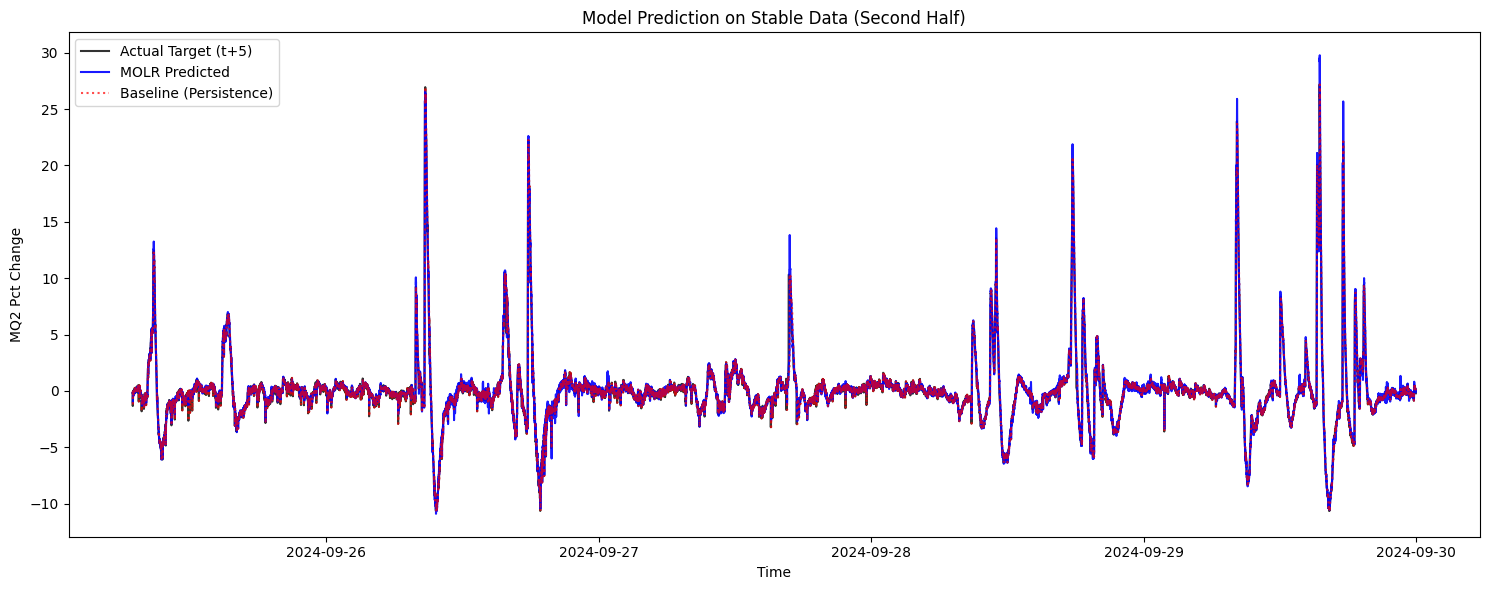

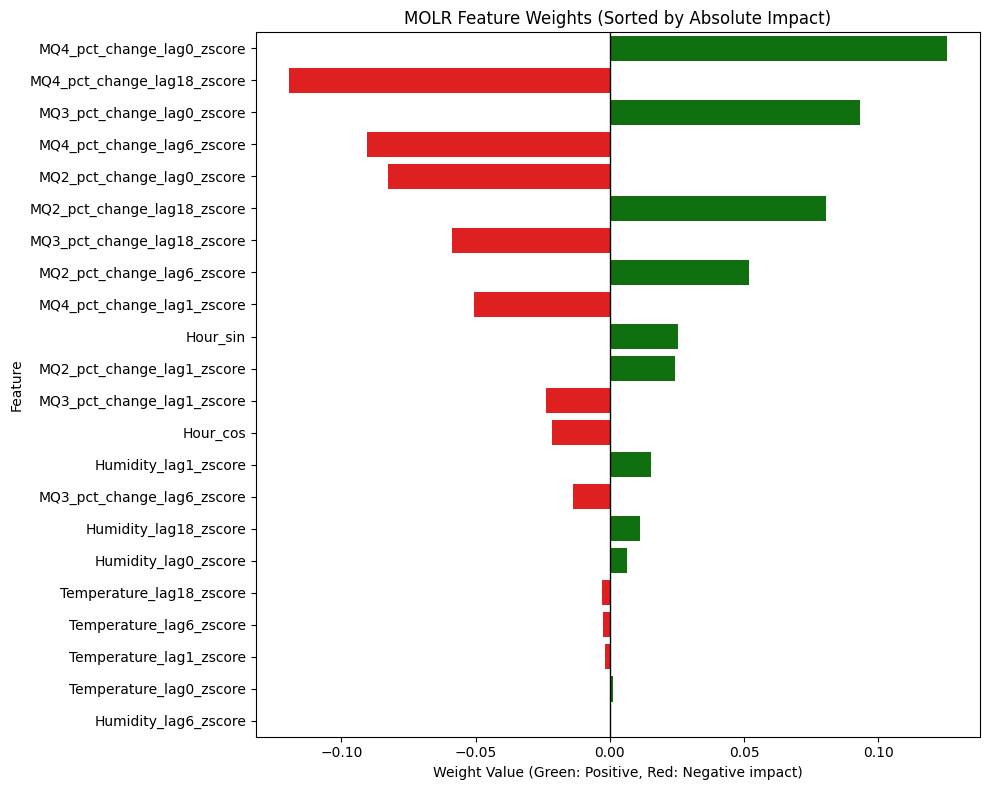

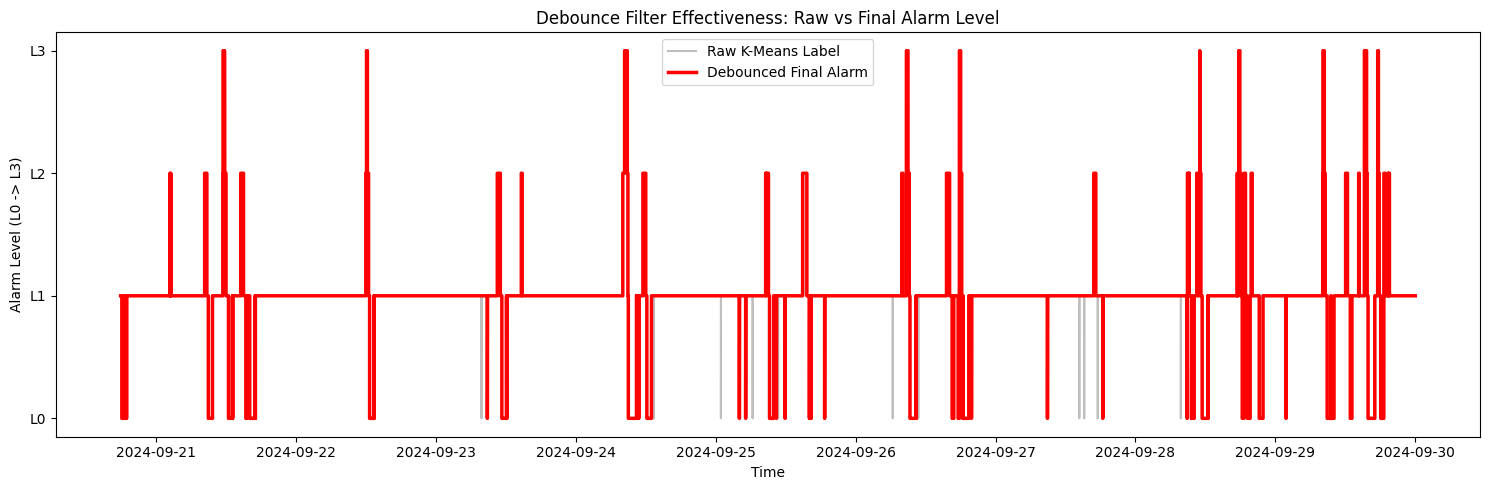


========== SO SÁNH MOLR VÀ AR(1) (TRÊN 50% DỮ LIỆU CUỐI) ==========

Phương trình AR(1) học được : Y(t+5) = 0.0011 + (0.9895) * Y(t)
------------------------------------------------------------
RMSE Baseline (Dự báo chép) : 0.5481
RMSE AR(1) (Hồi quy bậc 1)  : 0.5462
RMSE MOLR (Đa biến Online)  : 0.4826
------------------------------------------------------------
-> AR(1) cải thiện sai số   : 0.35%
-> MOLR cải thiện sai số    : 11.95%


In [ ]:

#note(ctrl+/ để comment và uncomment đoạn code)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# ĐỌC GOOGLE SHEET

# ===========================

#online
# sheet_id = "1kzYAxH2W3ia5sU__4ycZNgGVxvj1bSBiXHULtjBmhQo"

# url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

# raw = pd.read_csv(
#     url,
#     header=None,
#     low_memory=False
# )


#offline (nhớ chạy code upload file ở dưới trước)
file_path = "TD1_ESP32_SMELL_Part1.xlsx"
raw = pd.read_excel(
    file_path,
    header=None,
    dtype=str
)


header = raw.iloc[1]

df = raw.iloc[2:, :8].copy()

df.columns = header[:8]

df.columns = [
    "Date",
    "Time",
    "Status",
    "Temperature",
    "Humidity",
    "MQ2",
    "MQ3",
    "MQ4"
]
numeric_cols = [
    "Temperature",
    "Humidity",
    "MQ2",
    "MQ3",
    "MQ4"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.drop(
    columns=["Date", "Time"],
    inplace=True
)
#tạo bản copy dữ liệu thô
df_raw = df.copy(deep=True)
df = df_raw.copy()



#===================================
#Phase 1:Prepocessing
#===================================
#Median filter(lọc nhiễu)
sensor_cols = [
    "MQ2",
    "MQ3",
    "MQ4"
]
MEDIAN_WINDOW = 5
for sensor in sensor_cols:

    df[f"{sensor}_median"] = (
        df[sensor]
        .rolling(
            window=MEDIAN_WINDOW,
            center=False,
            min_periods=1
        )
        .median()
    )

#Moving average (làm trơn)
MA_WINDOW = 360
for sensor in sensor_cols:

    df[f"{sensor}_baseline"] = (
        df[f"{sensor}_median"]
        .rolling(
            window=MA_WINDOW,
            min_periods=1
        )
        .mean()
    )

#detrend (khử xu hướng vì k means không biết được xu hướng)
for sensor in sensor_cols:

    df[f"{sensor}_detrend"] = (
        df[f"{sensor}_median"]
        -
        df[f"{sensor}_baseline"]
    )

#Percent Change (% thay đổi so với mức nền của cảm biến đó)
EPS = 1e-8

for sensor in sensor_cols:

    df[f"{sensor}_pct_change"] = (
        df[f"{sensor}_detrend"]
        /
        (df[f"{sensor}_baseline"] + EPS)
    ) * 100


#check Nan
import numpy as np

print(
    np.isinf(
        df[
            [
                "MQ2_pct_change",
                "MQ3_pct_change",
                "MQ4_pct_change"
            ]
        ]
    ).sum()
)




#=========================================
#Phase 2:Chạy K-means với k=4 gán nhãn L0-L3
#=========================================
from sklearn.cluster import KMeans
import numpy as np

# ==========================
# KMeans trên MQ2_pct_change
# ==========================

X = df[["MQ2_pct_change"]].values

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

raw_labels = kmeans.fit_predict(X)

# ==========================
# Sắp xếp centroid tăng dần
# ==========================

centers = kmeans.cluster_centers_.flatten()

sorted_idx = np.argsort(centers)

# cluster gốc -> L0,L1,L2,L3
label_map = {
    old_cluster: new_level
    for new_level, old_cluster in enumerate(sorted_idx)
}

# Gán nhãn
df["pollution_level"] = [
    label_map[label]
    for label in raw_labels
]

# ==========================
# Kiểm tra centroid
# ==========================

print("\n========== Cluster Center ==========\n")

for new_level, old_cluster in enumerate(sorted_idx):

    print(
        f"L{new_level}"
        f" | centroid = {centers[old_cluster]:.3f}%"
        f" | samples = {(raw_labels == old_cluster).sum()}"
    )

# ==========================
# Thống kê số lượng từng mức
# ==========================

print("\n========== Pollution Level ==========\n")

print(
    df["pollution_level"]
    .value_counts()
    .sort_index()
)



# ==========================================
# Phase 3: FEATURE ENGINEERING Cho MOLR (tạo đặc trưng theo thời gian)
# ==========================================
import numpy as np

# 1. Tạo Target xa hơn (Dự báo trước 5 bước thời gian)
TARGET_STEP = 5
df[f"target_t{TARGET_STEP}"] = df["MQ2_pct_change"].shift(-TARGET_STEP)

# 2. Tạo Lag features (Bao gồm hiện tại lag0 và quá khứ lag1, lag2, lag3) (lag là thời gian quá khứ)
base_features = [
    "MQ2_pct_change",
    "MQ3_pct_change",
    "MQ4_pct_change",
    "Temperature",
    "Humidity"
]

lag_cols = []
for col in base_features:
    # Giá trị hiện tại (không lag)
    df[f"{col}_lag0"] = df[col]
    lag_cols.append(f"{col}_lag0")

    # Giá trị quá khứ
    for lag in [1, 6, 18]:
        lag_name = f"{col}_lag{lag}"
        df[lag_name] = df[col].shift(lag)
        lag_cols.append(lag_name)

# Khai báo lại cột Hour (phòng trường hợp mất)
if "Hour" not in df.columns:
    df["Hour"] = df["Timestamp"].dt.hour

# 3. Tạo Feature giờ theo chu kỳ (Sin/Cos)
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

# 4. Running Z-score chuẩn hóa dữ liệu
Z_WINDOW = 360

for col in lag_cols:
    roll = df[col].rolling(window=Z_WINDOW, min_periods=1)
    run_mean = roll.mean()
    run_std = roll.std().replace(0, 1e-8)

    # Tạo cột zscore riêng
    df[f"{col}_zscore"] = (df[col] - run_mean) / run_std

# 5. Dọn dẹp dữ liệu (xóa các dòng NaN do lệnh shift)
df_molr = df.dropna().copy()

# ==========================
# Kiểm tra kết quả
# ==========================
print("\n========== Feature Engineering Data ==========\n")
print(f"Số lượng features đầu vào: {len(lag_cols) + 2} (bao gồm Hour_sin/cos)")
print(f"Target dự báo: target_t{TARGET_STEP}\n")

# In thử để kiểm tra
display_cols = [
    "MQ2_pct_change_lag0_zscore",
    "MQ2_pct_change_lag1_zscore",
    "Hour_sin",
    f"target_t{TARGET_STEP}"
]
print(df_molr[display_cols].head())





#(thuật toán này dự đoán y xong rồi dùng y đê quay lại tính các trọng số w,b(bản chất chỉ là phép nhân vector))
# ==========================================
# Phase 4: XÂY DỰNG MOLR (SGD + RIDGE) - TARGET t+5
# ==========================================
import numpy as np

# 1. Chuẩn bị tập X (features)
# lag_cols lúc này đã bao gồm cả lag0 (hiện tại) và lag1, 2, 3 (quá khứ)
feature_cols = [f"{col}_zscore" for col in lag_cols] + ["Hour_sin", "Hour_cos"]
X = df_molr[feature_cols].values

# 2. Xử lý Target (Dự đoán Delta giữa t+5 và t)
y_current = df_molr["MQ2_pct_change"].values  # Giá trị thực tế hiện tại
y_true_t5 = df_molr["target_t5"].values       # Target t+5
delta_y = y_true_t5 - y_current               # Khoảng chênh lệch (Delta) cần học

# 3. Đánh giá Baseline Persistence Model (ŷ(t+5) = x(t))
# Giả định 5 bước sau nồng độ không đổi
rmse_baseline = np.sqrt(np.mean((y_true_t5 - y_current)**2))

# 4. Khởi tạo tham số cho MOLR
learning_rate = 0.001
l2_lambda = 0.01
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0.0

delta_pred_molr = np.zeros(len(delta_y))

# 5. Huấn luyện Online (SGD update từng mẫu)
for i in range(len(X)):
    x_i = X[i]
    d_i = delta_y[i]

    # Tính dự báo độ chênh lệch (Delta)
    d_hat = np.dot(w, x_i) + b
    delta_pred_molr[i] = d_hat

    # Tính sai số trên Delta
    error = d_hat - d_i

    # Cập nhật trọng số SGD
    w -= learning_rate * (error * x_i + l2_lambda * w)
    b -= learning_rate * error

# 6. Lấy kết quả Delta cộng trả lại vào y_current để ra dự báo gốc
y_pred_molr = y_current + delta_pred_molr
rmse_molr = np.sqrt(np.mean((y_true_t5 - y_pred_molr)**2))

# ==========================
# ĐÁNH GIÁ TRÊN 50% DỮ LIỆU CUỐI (Khi mô hình đã hội tụ)
# ==========================
split_idx = int(len(y_true_t5) * 0.5)

rmse_baseline = np.sqrt(np.mean((y_true_t5[split_idx:] - y_current[split_idx:])**2))
rmse_molr = np.sqrt(np.mean((y_true_t5[split_idx:] - y_pred_molr[split_idx:])**2))

# ==========================
# In kết quả so sánh
# ==========================
print("\n========== ĐÁNH GIÁ MÔ HÌNH MOLR (Giai đoạn hội tụ) ==========\n")
print(f"RMSE của Baseline Persistence Model : {rmse_baseline:.4f}")
print(f"RMSE của Mô hình MOLR (Online)      : {rmse_molr:.4f}")

improvement = ((rmse_baseline - rmse_molr) / rmse_baseline) * 100
print(f"-> MOLR cải thiện sai số được       : {improvement:.2f}%\n")




# ==========================================
# Phase 5: HẬU XỬ LÝ (LỌC CHỐNG BÁO ĐỘNG GIẢ - DÙNG CHUNG)
# ==========================================
def apply_debounce_filter(raw_sequence, n_confirm=3):
    """
    Hàm lọc chống dội (debounce).
    raw_sequence: Cột dữ liệu chứa các nhãn (0, 1, 2, 3) cần lọc.
    """
    final_levels = []

    # Lấy phần tử đầu tiên làm gốc (hỗ trợ cả Pandas Series và List/Array)
    current_state = raw_sequence.iloc[0] if hasattr(raw_sequence, 'iloc') else raw_sequence[0]
    pending_state = current_state
    confirm_count = 0

    for raw_state in raw_sequence:
        if raw_state == current_state:
            confirm_count = 0
            pending_state = raw_state
        else:
            if raw_state == pending_state:
                confirm_count += 1
                if confirm_count >= n_confirm:
                    current_state = raw_state
                    confirm_count = 0
            else:
                pending_state = raw_state
                confirm_count = 1

        final_levels.append(current_state)

    return final_levels
# --- CÁCH SỬ DỤNG CHO 2 LUỒNG ĐỘC LẬP ---

# 1. Áp dụng cho nhãn Hiện tại (K-Means) - Đổi tên cột lại thành Final_Alarm_Level để khớp với biểu đồ
df["Final_Alarm_Level"] = apply_debounce_filter(df["pollution_level"], n_confirm=3)

# 2. Áp dụng cho nhãn Tương lai (MOLR)
# Vì MOLR trả ra số % liên tục (y_pred_molr), ta cần dùng các mốc phân chia (b01, b12, b23)
# của K-Means để quy nó về nhãn L0, L1, L2, L3 trước khi nạp vào bộ lọc.
sorted_centers = np.sort(centers)
b01 = (sorted_centers[0] + sorted_centers[1]) / 2
b12 = (sorted_centers[1] + sorted_centers[2]) / 2
b23 = (sorted_centers[2] + sorted_centers[3]) / 2

# Tạo cột nhãn dự báo thô
df_molr["molr_predicted_raw"] = np.select(
    [y_pred_molr <= b01, y_pred_molr <= b12, y_pred_molr <= b23],
    [0, 1, 2],
    default=3
)

# Chạy qua bộ lọc Debounce để có nhãn tương lai sạch
df_molr["Final_Alarm_Future"] = apply_debounce_filter(df_molr["molr_predicted_raw"], n_confirm=3)







import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.graphics.tsaplots import plot_pacf

# ==============================================================================
# PHẦN 1: ĐÁNH GIÁ BẰNG SỐ LIỆU (TÍNH TOÁN & IN KẾT QUẢ)
# ==============================================================================

# 1. Tính toán trước cho Elbow & Silhouette (Chạy vòng lặp k)
print("\n========== ĐÁNH GIÁ SỐ CỤM K-MEANS (ELBOW & SILHOUETTE) ==========\n")
X_k = df[["MQ2_pct_change"]].values
k_range = range(2, 8)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=3)
    labels_eval = kmeans_eval.fit_predict(X_k)
    inertias.append(kmeans_eval.inertia_)
    score = silhouette_score(X_k, labels_eval, sample_size=5000, random_state=42)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia={kmeans_eval.inertia_:.2f} | Silhouette={score:.4f}")

# 2. Đánh giá hiệu quả bộ lọc Debounce
print("\n========== KẾT QUẢ BỘ LỌC CHỐNG BÁO ĐỘNG GIẢ ==========\n")
raw_flips = (df["pollution_level"] != df["pollution_level"].shift()).sum()
final_flips = (df["Final_Alarm_Level"] != df["Final_Alarm_Level"].shift()).sum()

print(f"Số lần trạng thái nhảy mức (Chưa lọc) : {raw_flips} lần")
print(f"Số lần trạng thái nhảy mức (Đã lọc)   : {final_flips} lần")
print(f"-> Bộ lọc chặn được {raw_flips - final_flips} lần còi báo động chập chờn.")

# 3. Đánh giá MOLR ở giai đoạn ổn định (50% cuối)
split_idx = int(len(y_true_t5) * 0.5)
y_true_stable = y_true_t5[split_idx:]
y_pred_baseline_stable = y_current[split_idx:]
y_pred_molr_stable = y_pred_molr[split_idx:]

rmse_baseline_stable = np.sqrt(np.mean((y_true_stable - y_pred_baseline_stable)**2))
rmse_molr_stable = np.sqrt(np.mean((y_true_stable - y_pred_molr_stable)**2))

print("\n========== ĐÁNH GIÁ MOLR (GIAI ĐOẠN ỔN ĐỊNH) ==========\n")
print(f"RMSE Baseline (Đã hội tụ) : {rmse_baseline_stable:.4f}")
print(f"RMSE MOLR (Đã hội tụ)     : {rmse_molr_stable:.4f}")
improvement_stable = ((rmse_baseline_stable - rmse_molr_stable) / rmse_baseline_stable) * 100
print(f"-> MOLR thực tế cải thiện : {improvement_stable:.2f}%")

# 4. Kiểm tra Multicollinearity (Đa cộng tuyến)
corr_matrix = df_molr[[
    "MQ2_pct_change_lag0_zscore",
    "MQ2_pct_change_lag1_zscore",
    "MQ2_pct_change_lag6_zscore",
    "MQ2_pct_change_lag18_zscore",
]].corr()
print("\n========== CORRELATION MATRIX (MQ2 lag0-3) ==========\n")
print(corr_matrix)

# 5. Phân tích ngoại lệ (Spike ở nhiệt độ thấp)
low_temp_spikes = df[(df["Temperature"] < 30) & (df["pollution_level"].isin([2, 3]))]
print("\n========== PHÂN TÍCH NHIỄU NHIỆT ĐỘ THẤP (<30°C) ==========\n")
print(f"Số lượng cảnh báo L2/L3 khi nhiệt độ thấp: {len(low_temp_spikes)}")
if len(low_temp_spikes) > 0:
    print("Phân bổ spike theo giờ:")
    print(low_temp_spikes["Hour"].value_counts().sort_index())


# ==============================================================================
# PHẦN 2: BIỂU ĐỒ (VISUALIZATION)
# ==============================================================================
print("\n========== ĐANG VẼ BIỂU ĐỒ... ==========\n")

# Cấu hình dữ liệu 7 ngày cho biểu đồ 1
start_time = df["Timestamp"].min()
df_plot_7d = df[df["Timestamp"] < (start_time + pd.Timedelta(days=7))]
date_format = mdates.DateFormatter('%b %d')

# I. Biểu đồ 1: Signal Processing Pipeline:Lọc nhiễu và trích xuất Baseline nền (7 ngày)
fig, ax = plt.subplots(figsize=(15, 6))
fig.suptitle('Signal Processing Pipeline', fontsize=16)
sensor = 'MQ2'
ax.plot(df_plot_7d["Timestamp"], df_plot_7d[sensor], label='1. Raw Sensor Data', color='goldenrod', alpha=0.6, linewidth=1.2)
ax.plot(df_plot_7d["Timestamp"], df_plot_7d[f'{sensor}_median'], label='2. After Median Filter', color='blue', linewidth=1.5, alpha=0.8)
ax.plot(df_plot_7d["Timestamp"], df_plot_7d[f'{sensor}_baseline'], label='3. Baseline (Đường nền)', color='red', linestyle='-', linewidth=2.5)
ax.set_ylabel('Sensor Value (ADC)')
ax.legend(loc='upper right', fontsize=11)
ax.xaxis.set_major_formatter(date_format)
ax.xaxis.set_major_locator(mdates.DayLocator())
#plt.xlabel('Thời gian đo', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# II. Biểu đồ 2: Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
# Elbow
ax1.plot(k_range, inertias, marker='o', linestyle='-', color='b')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.axvline(x=4, color='r', linestyle='--', label='k=4 (Chosen)')
ax1.legend()
# Silhouette
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Score')
ax2.axvline(x=4, color='r', linestyle='--', label='k=4 (Chosen)')
ax2.legend()
plt.tight_layout()
plt.show()

# III. Biểu đồ 3: Scatter Hour vs Pct_change
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Hour', y='MQ2_pct_change', hue='pollution_level', palette='tab10', alpha=0.6)
for i, c in enumerate(np.sort(centers)):
    plt.axhline(y=c, color='black', linestyle='--', linewidth=2, alpha=0.8, label=f'Centroid L{i}' if i==0 else "")
plt.title('Cluster Distribution: Hour of Day vs MQ2 Pct_Change')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('MQ2 Pct_Change from Baseline (%)')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#IV.Bảng 4:TRÍCH XUẤT LUẬT CẢNH BÁO TỪ TÂM CỤM K-MEANS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Lấy các tâm cụm đã sắp xếp từ thuật toán
sorted_centers = np.sort(centers)

# 2. Tính các đường ranh giới (Trung điểm giữa các tâm cụm)
b01 = (sorted_centers[0] + sorted_centers[1]) / 2  # Cắt L0 và L1
b12 = (sorted_centers[1] + sorted_centers[2]) / 2  # Cắt L1 và L2
b23 = (sorted_centers[2] + sorted_centers[3]) / 2  # Cắt L2 và L3

# 3. Tạo dữ liệu bảng theo định dạng chuẩn
table_data = {
    "Phân loại mức ô nhiễm": [
        "L0 – Mức an toàn",
        "L1 – Mức trung bình",
        "L2 – Mức cao",
        "L3 – Mức rất cao"
    ],
    "Thay đổi theo % của chỉ số cảm biến": [
        f"L0 ≤ {b01:.1f}%",
        f"{b01:.1f}% < L1 ≤ {b12:.1f}%",
        f"{b12:.1f}% < L2 ≤ {b23:.1f}%",
        f"L3 > {b23:.1f}%"
    ]
}
df_rules = pd.DataFrame(table_data)

# 4. Vẽ bảng bằng Matplotlib cho đẹp (giống hình mẫu)
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off') # Tắt trục tọa độ

# Tạo bảng
tbl = ax.table(cellText=df_rules.values,
               colLabels=df_rules.columns,
               cellLoc='center',
               loc='center',
               bbox=[0, 0, 1, 1])

# Định dạng Font chữ và kích thước
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
# Bôi đậm hàng tiêu đề
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.title("Bảng quy tắc ngưỡng cảnh báo tự động (Trích xuất từ K-Means)", fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.show()



# V. Biểu đồ 5: PACF (Chứng minh Lag)
plt.figure(figsize=(12, 5))
plot_pacf(df_molr["MQ2_pct_change"].dropna(), lags=20, method='ywm',
          title="Partial Autocorrelation Function (PACF) của MQ2 Pct Change", ax=plt.gca())
plt.xlabel("Độ trễ (Lags - Số nhịp thời gian trong quá khứ)")
plt.ylabel("Hệ số tương quan")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#VI. Bảng 6:ABLATION TEST (ĐÁNH GIÁ CÁC BỘ LAG)
import numpy as np
import pandas as pd

def run_lag_ablation(df_input, lag_sets, base_features, target_step=5):
    results = []

    # Duyệt qua từng kịch bản lag
    for name, lags in lag_sets.items():
        print(f"Đang chạy test kịch bản: {name} (Lags: {lags}) ...")
        df_test = df_input.copy()

        # 1. Target
        df_test[f"target_t{target_step}"] = df_test["MQ2_pct_change"].shift(-target_step)

        # 2. Tạo Lag
        lag_cols = []
        for col in base_features:
            df_test[f"{col}_lag0"] = df_test[col]
            lag_cols.append(f"{col}_lag0")
            for lag in lags:
                lag_name = f"{col}_lag{lag}"
                df_test[lag_name] = df_test[col].shift(lag)
                lag_cols.append(lag_name)

        # 3. Tạo Feature Giờ
        if "Hour" not in df_test.columns:
            df_test["Hour"] = df_test["Timestamp"].dt.hour
        df_test["Hour_sin"] = np.sin(2 * np.pi * df_test["Hour"] / 24)
        df_test["Hour_cos"] = np.cos(2 * np.pi * df_test["Hour"] / 24)

        # 4. Tính Z-score
        for col in lag_cols:
            roll = df_test[col].rolling(window=360, min_periods=1)
            mean_col = roll.mean()
            std_col = roll.std().replace(0, 1e-8)
            df_test[f"{col}_zscore"] = (df_test[col] - mean_col) / std_col

        df_clean = df_test.dropna().copy()

        # 5. Huấn luyện MOLR nhanh
        feature_cols = [f"{col}_zscore" for col in lag_cols] + ["Hour_sin", "Hour_cos"]
        X = df_clean[feature_cols].values
        y_current = df_clean["MQ2_pct_change"].values
        y_true_t5 = df_clean[f"target_t{target_step}"].values
        delta_y = y_true_t5 - y_current

        w = np.zeros(X.shape[1])
        b = 0.0
        delta_pred = np.zeros(len(delta_y))

        lr = 0.001
        l2 = 0.01

        for i in range(len(X)):
            x_i = X[i]
            d_i = delta_y[i]
            d_hat = np.dot(w, x_i) + b
            delta_pred[i] = d_hat
            error = d_hat - d_i
            w -= lr * (error * x_i + l2 * w)
            b -= lr * error

        # 6. Đánh giá RMSE ở 50% dữ liệu cuối (Ổn định)
        split_idx = int(len(y_true_t5) * 0.5)
        y_true_stable = y_true_t5[split_idx:]
        y_current_stable = y_current[split_idx:]
        y_pred_stable = y_current_stable + delta_pred[split_idx:]

        rmse_baseline = np.sqrt(np.mean((y_true_stable - y_current_stable) ** 2))
        rmse_molr = np.sqrt(np.mean((y_true_stable - y_pred_stable) ** 2))
        improvement = ((rmse_baseline - rmse_molr) / rmse_baseline) * 100

        # Thêm kết quả vào danh sách
        results.append({
            "Kịch bản (Tên)": name,
            "Cấu hình Lags": str(lags),
            "Số lượng Features": X.shape[1],
            "RMSE Baseline": round(rmse_baseline, 4),
            "RMSE MOLR": round(rmse_molr, 4),
            "Cải thiện (%)": round(improvement, 2)
        })

    # Chuyển list dictionary thành DataFrame
    return pd.DataFrame(results)

# --- THỰC THI ---
print("\n========== CHẠY ABLATION TEST SO SÁNH LAG ==========\n")

base_features_test = ["MQ2_pct_change", "MQ3_pct_change", "MQ4_pct_change", "Temperature", "Humidity"]

lag_sets_to_test = {
    "current_1_6_18":   [1, 6, 18],
    "pacf_peaks_old":   [1, 3, 8],
    "lag1_only":        [1],
    "dense_short":      [1, 2, 3, 4, 5],

    # --- CÁC BỘ LAG MỚI RÚT RA TỪ BIỂU ĐỒ PACF TRÊN ---
    "pacf_strongest_1_3": [1, 3],       # Chỉ lấy 2 tín hiệu mạnh nhất (Lag 1 và Lag 3)
    "pacf_visible_peaks_1_3_6": [1, 3, 6] # Lấy toàn bộ các đỉnh quan sát được bằng mắt
}

# Gọi hàm
results_df = run_lag_ablation(df, lag_sets_to_test, base_features_test)

print("\n========== BẢNG TỔNG HỢP KẾT QUẢ ABLATION TEST ==========\n")
# Print trực tiếp DataFrame
print(results_df.to_markdown(index=False))


#VII. Biểu đồ 7: MOLR Predicted vs Baseline
plt.figure(figsize=(15, 6))
time_x = df_molr["Timestamp"].iloc[split_idx:]
plt.plot(time_x, y_true_t5[split_idx:], label='Actual Target (t+5)', color='black', alpha=0.8)
plt.plot(time_x, y_pred_molr[split_idx:], label='MOLR Predicted', color='blue', alpha=0.9)
plt.plot(time_x, y_current[split_idx:], label='Baseline (Persistence)', color='red', linestyle=':', alpha=0.7)
plt.title('Model Prediction on Stable Data (Second Half)')
plt.xlabel('Time')
plt.ylabel('MQ2 Pct Change')
plt.legend()
plt.tight_layout()
plt.show()

#VIII. Biểu đồ 8: Trọng số W (Feature Impact)
df_weights = pd.DataFrame({'feature': feature_cols, 'weight': w})
df_weights['abs_weight'] = df_weights['weight'].abs()
df_weights_sorted = df_weights.sort_values(by='abs_weight', ascending=False)
plt.figure(figsize=(10, 8))
colors = ['green' if val > 0 else 'red' for val in df_weights_sorted['weight']]
sns.barplot(x='weight', y='feature', data=df_weights_sorted, hue='feature', palette=colors, legend=False)
plt.title('MOLR Feature Weights (Sorted by Absolute Impact)')
plt.xlabel('Weight Value (Green: Positive, Red: Negative impact)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


#IX. Biểu đồ 9: Debounce Filter Step Plot
plt.figure(figsize=(15, 5))
plt.step(df["Timestamp"], df['pollution_level'], label='Raw K-Means Label', color='gray', alpha=0.5, where='post')
plt.step(df["Timestamp"], df['Final_Alarm_Level'], label='Debounced Final Alarm', color='red', linewidth=2.5, where='post')
plt.title('Debounce Filter Effectiveness: Raw vs Final Alarm Level')
plt.xlabel('Time')
plt.ylabel('Alarm Level (L0 -> L3)')
plt.yticks([0, 1, 2, 3], ['L0', 'L1', 'L2', 'L3'])
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# MÔ HÌNH AR(1) ĐỂ SO SÁNH (DIRECT MULTI-STEP)
# ==========================================
from sklearn.linear_model import LinearRegression

# 1. Chuẩn bị dữ liệu cho AR(1)
# AR(1) chỉ dùng đúng 1 biến quá khứ gần nhất (y_current tại thời điểm t)
X_ar1 = y_current.reshape(-1, 1)
y_target = y_true_t5

# 2. Chia tập Train / Test (Công bằng với MOLR)
# MOLR mất 50% dữ liệu đầu để hội tụ (Warm-up).
# Do đó, ta lấy 50% đầu cho AR(1) huấn luyện, và 50% cuối để test.
split_idx = int(len(y_target) * 0.5)

X_train_ar = X_ar1[:split_idx]
y_train_ar = y_target[:split_idx]

X_test_ar = X_ar1[split_idx:]
y_test_ar = y_target[split_idx:]

# 3. Huấn luyện mô hình AR(1) Batch
ar1_model = LinearRegression()
ar1_model.fit(X_train_ar, y_train_ar)

# Lấy hệ số phi và hằng số C
phi = ar1_model.coef_[0]
C = ar1_model.intercept_

# 4. Dự đoán trên tập Test (Giai đoạn ổn định) và tính RMSE
y_pred_ar1_stable = ar1_model.predict(X_test_ar)
rmse_ar1_stable = np.sqrt(np.mean((y_test_ar - y_pred_ar1_stable)**2))

# ==========================
# In bảng tổng hợp thi đấu
# ==========================
print("\n========== SO SÁNH MOLR VÀ AR(1) (TRÊN 50% DỮ LIỆU CUỐI) ==========\n")
print(f"Phương trình AR(1) học được : Y(t+5) = {C:.4f} + ({phi:.4f}) * Y(t)")
print("-" * 60)
print(f"RMSE Baseline (Dự báo chép) : {rmse_baseline_stable:.4f}")
print(f"RMSE AR(1) (Hồi quy bậc 1)  : {rmse_ar1_stable:.4f}")
print(f"RMSE MOLR (Đa biến Online)  : {rmse_molr_stable:.4f}")
print("-" * 60)

imp_ar1 = ((rmse_baseline_stable - rmse_ar1_stable) / rmse_baseline_stable) * 100
print(f"-> AR(1) cải thiện sai số   : {imp_ar1:.2f}%")
print(f"-> MOLR cải thiện sai số    : {improvement_stable:.2f}%")

In [ ]:
#train offline
from google.colab import files

uploaded = files.upload()

Saving TD1_ESP32_SMELL_Part1.xlsx to TD1_ESP32_SMELL_Part1.xlsx
